# Customer Churn Analysis & Prediction

## Executive Summary

**Dataset:**  
Customer Churn Dataset

**Business Objective:**  
Identify why customers churn and estimate the business impact.

**Key Findings:**
- **Churn Rate:** To be calculated in Business KPIs section
- **Revenue Lost:** To be calculated in Business KPIs section
- **High Risk Segment:** To be identified from churn analysis
- **Complaint Impact:** To be identified from complaint analysis
- **Average Tenure:** To be calculated in Business KPIs section

**Business Recommendation:**  
To be filled after analysis.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Data Loading

In [3]:
# Data Import: db file to pandas, storing each table to a separate df

from pathlib import Path

# Connect to the real SQLite database from either project root or notebooks folder
candidate_db_paths = [
    Path('../data/customer_churn.db'),
    Path('data/customer_churn.db'),
    Path('customer_churn.db')
]

db_path = next((path for path in candidate_db_paths if path.exists() and path.stat().st_size > 0), None)

if db_path is None:
    raise FileNotFoundError('Could not find a valid customer_churn.db file. Expected it inside the data folder.')

conn = sqlite3.connect(db_path)

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

print('Database loaded from:', db_path)


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support
Database loaded from: ..\data\customer_churn.db


In [4]:
# Print table names and column names
conn = sqlite3.connect(db_path)

for table_name in tables['name']:
    print()
    print(f"Table Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()



Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


### 2. Data Cleaning

In [5]:
# df_db_customer.head() # customer table
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
516,1495-DJSPW,anaya,India,Delhi,Male,1996-06-21 00:00:00,music,None
517,1496-AZPTW,reyansh,India,Maharashtra,Female,1992-02-01 00:00:00,movie,None
518,1497-FHRIT,kabir,India,Nagaland,Male,1984-05-24 00:00:00,sports,None
519,1498-PLVIM,saanvi,Nepal,Kathmandu,Women,1983-09-14 00:00:00,gaming,None
520,1499-LWQMQ,aditya,India,Karnataka,Men,1994-06-04 00:00:00,food,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  521 non-null    object
 1   name        521 non-null    object
 2   country     495 non-null    object
 3   state       521 non-null    object
 4   gender      521 non-null    object
 5   dob         521 non-null    object
 6   interests   440 non-null    object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 32.7+ KB


In [7]:
# a. rename col - name to customer_name

# Safe to rerun: only renames if the original column exists.
df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)

In [8]:
# b. drop columns - interest and pincode

# Safe to rerun because missing columns are ignored.
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True, errors='ignore')

In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     521 non-null    object
 1   customer_name  521 non-null    object
 2   country        495 non-null    object
 3   state          521 non-null    object
 4   gender         521 non-null    object
 5   dob            521 non-null    object
dtypes: object(6)
memory usage: 24.5+ KB


In [10]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'], errors='coerce')

In [11]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [12]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [13]:
# e. fix missing values - country

# df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
29,1008-KASRH,tara,None,Telangana,Male,1975-04-09
42,1021-MPMHE,rohan,None,Kathmandu,Male,1999-12-02
128,1107-TUVTP,kabir,None,Nagaland,Female,1965-07-14
149,1128-VYBBD,rohan,None,Nagaland,Female,1984-10-18
177,1156-SHPJC,saanvi,None,Kathmandu,Female,1970-05-25
182,1161-LFIXW,aditya,None,Rajasthan,Male,1972-04-23
206,1185-EBWZJ,reyansh,None,Gujarat,Female,1969-08-07


In [14]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
df_db_customer[df_db_customer['country'].isna()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [16]:
df_db_subscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               521 non-null    object 
 1   subscription_start_date  521 non-null    object 
 2   subscription_type        521 non-null    object 
 3   renewal_date             521 non-null    object 
 4   plan_type                521 non-null    object 
 5   contract_type            521 non-null    object 
 6   cancellation_date        150 non-null    object 
 7   cancellation_reason      150 non-null    object 
 8   monthly_charges          521 non-null    float64
 9   cltv                     521 non-null    int64  
 10  churn_score              521 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 44.9+ KB


In [18]:
# change data type to date - subscription_start_date, renewal_date, cancellation_date

date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime, errors='coerce')
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               521 non-null    object        
 1   subscription_start_date  521 non-null    datetime64[ns]
 2   subscription_type        521 non-null    object        
 3   renewal_date             521 non-null    datetime64[ns]
 4   plan_type                521 non-null    object        
 5   contract_type            521 non-null    object        
 6   cancellation_date        150 non-null    datetime64[ns]
 7   cancellation_reason      150 non-null    object        
 8   monthly_charges          521 non-null    float64       
 9   cltv                     521 non-null    int64         
 10  churn_score              521 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 44.9+ KB


In [19]:
# Check converted subscription date columns

df_db_subscription[['subscription_start_date', 'renewal_date', 'cancellation_date']].dtypes

subscription_start_date    datetime64[ns]
renewal_date               datetime64[ns]
cancellation_date          datetime64[ns]
dtype: object

In [20]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [21]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      226 non-null    object
 1   complaint_date  226 non-null    object
 2   escalations     226 non-null    object
 3   csat_score      226 non-null    int64 
 4   col_1           0 non-null      object
 5   comment         221 non-null    object
dtypes: int64(1), object(5)
memory usage: 10.7+ KB


In [22]:
# drop columns

# Safe to rerun because missing columns are ignored.
df_db_support.drop(columns=['col_1', 'comment'], inplace=True, errors='ignore')

In [23]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'], errors='coerce')
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      226 non-null    object        
 1   complaint_date  226 non-null    datetime64[ns]
 2   escalations     226 non-null    object        
 3   csat_score      226 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.2+ KB


### 3. Feature Engineering & Data Analysis

##### Create a new col

In [24]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


##### Merge Dataframes - JOINs

In [25]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [26]:
df_db_subscription.shape

(521, 12)

In [27]:
df.shape

(595, 20)

In [28]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 521
df_db_customer unique value: 521
df_db_support unique value: 152
df_db_support all value: 226


In [29]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
221,1488-PXLRI,2026-01-18,N,72
222,1489-GXCGM,2024-05-06,N,52
223,1492-CJHBP,2023-04-30,Y,29
224,1498-PLVIM,2021-10-27,Y,39


In [30]:
# Count complaint records before removing duplicate customer rows.
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [31]:
# Keep latest complaint record per customer for a clean one-row-per-customer merge.
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [32]:
df_db_support['customerid'].size

152

In [33]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [34]:
df.shape

(521, 21)

##### Export dataframe

In [35]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

## 4. Business KPIs

These KPIs answer the first questions a CEO would ask: customer base size, churn health, revenue impact, customer value, loyalty, and service quality.

In [36]:
# Prepare business-ready features for KPI and analysis sections.
df['complaint_count'] = df['complaint_count'].fillna(0)
df['escalations'] = df['escalations'].fillna('N')
df['csat_score'] = df['csat_score'].fillna(df['csat_score'].median())
df['cancellation_reason'] = df['cancellation_reason'].fillna('Active Customer')

# Customer age and age groups
today = pd.Timestamp.today().normalize()
df['customer_age'] = ((today - df['dob']).dt.days // 365).astype('Int64')
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 24, 34, 44, 54, 120],
    labels=['18-24', '25-34', '35-44', '45-54', '55+']
)

# Tenure and revenue features
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
df['tenure_months'] = (df['tenure_days'] / 30.44).round(1)
df['revenue_lost'] = np.where(df['churn_flag'] == 1, df['monthly_charges'], 0)
df['escalation_flag'] = np.where(df['escalations'] == 'Y', 1, 0)

# Churn risk segment
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['Low', 'Medium', 'High']
df['churn_risk'] = np.select(conditions, choices, default='Unknown')


# Customer value segment based on monthly charges.
# Dataset charges are below Rs 50, so tighter bins create useful Low/Medium/High groups.
df['customer_segment'] = pd.cut(
    df['monthly_charges'],
    bins=[0, 10, 20, float('inf')],
    labels=['Low Value', 'Medium Value', 'High Value']
)

# KPI calculations
total_customers = df['customerid'].nunique()
churned_customers = int(df['churn_flag'].sum())
active_customers = total_customers - churned_customers
churn_rate = df['churn_flag'].mean() * 100
total_revenue = df['monthly_charges'].sum()
revenue_lost = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
arpu = total_revenue / total_customers
avg_tenure = df['tenure_months'].mean()
total_complaints = df['complaint_count'].sum()
complaint_rate = (df['complaint_count'].gt(0).mean() * 100)

kpi_df = pd.DataFrame({
    'KPI': [
        'Total Customers', 'Active Customers', 'Churned Customers', 'Churn Rate',
        'Total Revenue', 'Revenue Lost', 'ARPU', 'Avg Customer Tenure',
        'Total Complaints', 'Complaint Rate'
    ],
    'Value': [
        total_customers,
        active_customers,
        churned_customers,
        f'{churn_rate:.2f}%',
        f'Rs {total_revenue:,.2f}',
        f'Rs {revenue_lost:,.2f}',
        f'Rs {arpu:,.2f}',
        f'{avg_tenure:.1f} Months',
        int(total_complaints),
        f'{complaint_rate:.2f}%'
    ]
})

kpi_df

,KPI,Value
0,Total Customers,521
1,Active Customers,371
2,Churned Customers,150
3,Churn Rate,28.79%
4,Total Revenue,"Rs 7,933.79"
5,Revenue Lost,"Rs 1,994.50"
6,ARPU,Rs 15.23
7,Avg Customer Tenure,43.2 Months
8,Total Complaints,226
9,Complaint Rate,29.17%


## 5. Customer Analysis

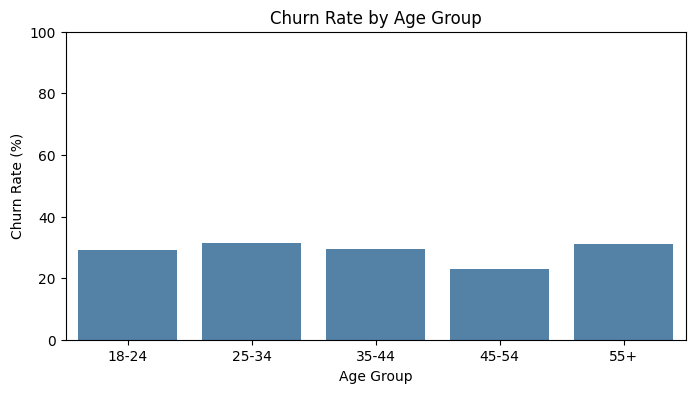

,age_group,customers,churn_rate,churn_rate_pct
1,25-34,143,0.314685,31.468531
4,55+,84,0.309524,30.952381
2,35-44,126,0.293651,29.365079
0,18-24,55,0.290909,29.090909
3,45-54,113,0.230088,23.008850


In [37]:
# Which age group churns the most?
age_churn = (
    df.groupby('age_group', observed=False)
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'))
      .reset_index()
)
age_churn['churn_rate_pct'] = age_churn['churn_rate'] * 100

plt.figure(figsize=(8, 4))
sns.barplot(data=age_churn, x='age_group', y='churn_rate_pct', color='steelblue')
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

age_churn.sort_values('churn_rate_pct', ascending=False)

**Business Insight:** Customers aged 25-34 have the highest churn rate at 31.47%, followed by the 55+ group at 30.95% and the 35-44 group at 29.37%. Retention offers should prioritize younger adult customers first, while also monitoring older customers.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\3432345537.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plan_churn, x='plan_type', y='churn_rate_pct', palette='Set2')


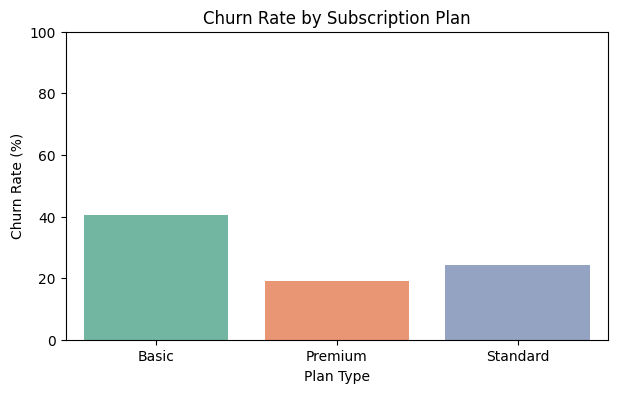

,plan_type,customers,churn_rate,churn_rate_pct
0,Basic,188,0.404255,40.425532
2,Standard,201,0.243781,24.378109
1,Premium,132,0.189394,18.939394


In [38]:
# Which subscription plan has the highest churn?
plan_churn = (
    df.groupby('plan_type')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'))
      .reset_index()
)
plan_churn['churn_rate_pct'] = plan_churn['churn_rate'] * 100

plt.figure(figsize=(7, 4))
sns.barplot(data=plan_churn, x='plan_type', y='churn_rate_pct', palette='Set2')
plt.title('Churn Rate by Subscription Plan')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

plan_churn.sort_values('churn_rate_pct', ascending=False)

**Business Insight:** Basic plan customers have the highest churn rate at 40.43% across 188 customers. Standard customers churn at 24.38% and Premium customers at 18.94%, so the Basic plan should be reviewed for pricing, content value, and onboarding quality.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\490093287.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_churn.sort_values('churn_rate_pct', ascending=False), x='state', y='churn_rate_pct', palette='viridis')


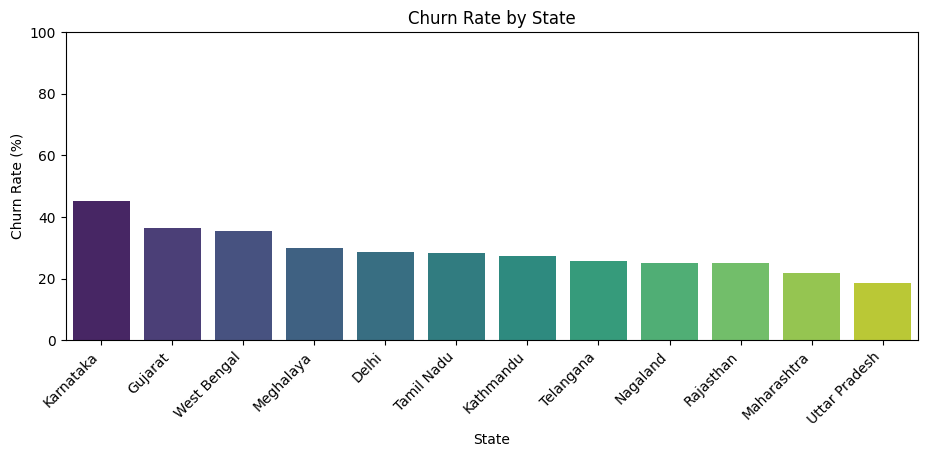

,state,customers,churn_rate,churn_rate_pct
2,Karnataka,42,0.452381,45.238095
1,Gujarat,44,0.363636,36.363636
11,West Bengal,31,0.354839,35.483871
5,Meghalaya,47,0.297872,29.787234
0,Delhi,49,0.285714,28.571429
8,Tamil Nadu,46,0.282609,28.260870
3,Kathmandu,55,0.272727,27.272727
9,Telangana,39,0.256410,25.641026
6,Nagaland,48,0.250000,25.000000
7,Rajasthan,36,0.250000,25.000000


In [39]:
# Which state has the highest churn?
state_churn = (
    df.groupby('state')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'))
      .reset_index()
)
state_churn['churn_rate_pct'] = state_churn['churn_rate'] * 100

plt.figure(figsize=(11, 4))
sns.barplot(data=state_churn.sort_values('churn_rate_pct', ascending=False), x='state', y='churn_rate_pct', palette='viridis')
plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.show()

state_churn.sort_values('churn_rate_pct', ascending=False)

**Business Insight:** Karnataka shows the highest churn rate at 45.24%, followed by Gujarat at 36.36% and West Bengal at 35.48%. These states should be treated as priority areas for deeper churn investigation.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\333412020.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_churn, x='gender', y='churn_rate_pct', palette='pastel')


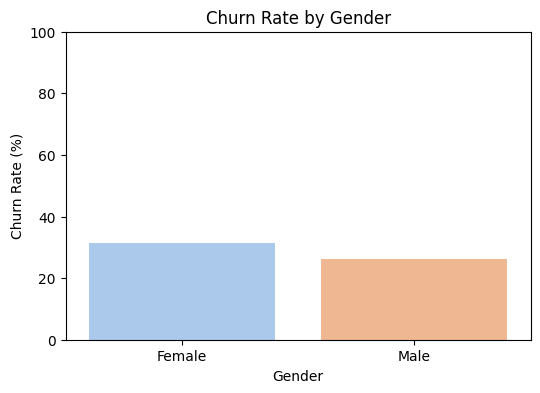

,gender,customers,churn_rate,churn_rate_pct
0,Female,257,0.315175,31.517510
1,Male,264,0.261364,26.136364


In [40]:
# Which gender churns more?
gender_churn = (
    df.groupby('gender')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'))
      .reset_index()
)
gender_churn['churn_rate_pct'] = gender_churn['churn_rate'] * 100

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_churn, x='gender', y='churn_rate_pct', palette='pastel')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

gender_churn.sort_values('churn_rate_pct', ascending=False)

**Business Insight:** Female customers churn at 31.52%, compared with 26.14% for male customers. Campaign performance should be reviewed by gender along with plan type and complaints before taking action.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\1788510288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='contract_type', y='churn_rate_pct', palette='Set1')


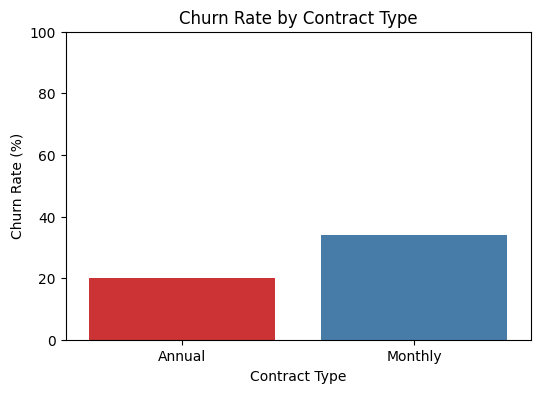

,contract_type,customers,churn_rate,avg_tenure,churn_rate_pct
0,Annual,198,0.202020,46.685354,20.202020
1,Monthly,323,0.340557,41.049226,34.055728


In [41]:
# Which contract type is most stable?
contract_churn = (
    df.groupby('contract_type')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'), avg_tenure=('tenure_months', 'mean'))
      .reset_index()
)
contract_churn['churn_rate_pct'] = contract_churn['churn_rate'] * 100

plt.figure(figsize=(6, 4))
sns.barplot(data=contract_churn, x='contract_type', y='churn_rate_pct', palette='Set1')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

contract_churn.sort_values('churn_rate_pct')

**Business Insight:** Annual contracts are the more stable segment with 20.20% churn, while monthly contracts churn at 34.06%. Monthly customers are about 1.7 times more likely to churn than annual customers.

## 6. Revenue Analysis

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\1889446325.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_plan, x='plan_type', y='total_revenue', palette='Set2')


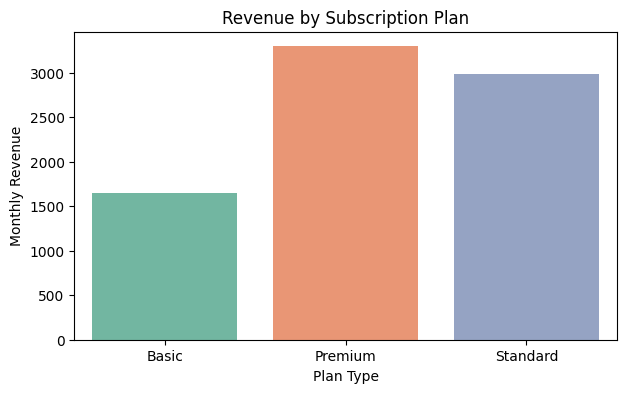

,plan_type,total_revenue,customers,churn_rate,revenue_share_pct
1,Premium,3297.68,132,0.189394,41.565002
2,Standard,2981.99,201,0.243781,37.585946
0,Basic,1654.12,188,0.404255,20.849052


In [42]:
# Revenue by subscription plan
revenue_by_plan = (
    df.groupby('plan_type')
      .agg(total_revenue=('monthly_charges', 'sum'), customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'))
      .reset_index()
)
revenue_by_plan['revenue_share_pct'] = revenue_by_plan['total_revenue'] / revenue_by_plan['total_revenue'].sum() * 100

plt.figure(figsize=(7, 4))
sns.barplot(data=revenue_by_plan, x='plan_type', y='total_revenue', palette='Set2')
plt.title('Revenue by Subscription Plan')
plt.xlabel('Plan Type')
plt.ylabel('Monthly Revenue')
plt.show()

revenue_by_plan.sort_values('total_revenue', ascending=False)

**Business Insight:** Premium customers generate the highest monthly revenue at Rs 3,297.68, contributing 41.57% of total revenue, while also having the lowest churn rate at 18.94%. This is the strongest high-value segment.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\1078622789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_segment, x='churn_risk', y='total_revenue', order=['Low', 'Medium', 'High'], palette='coolwarm')


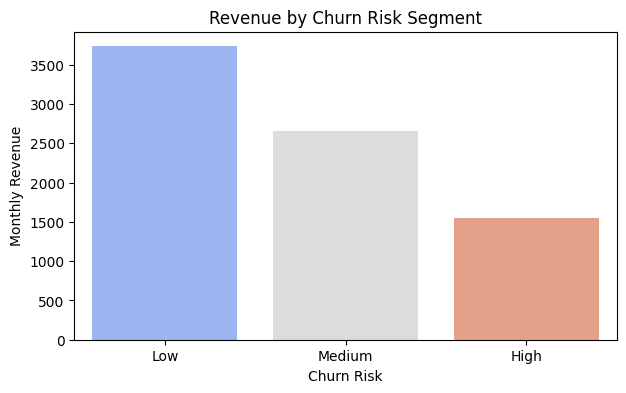

,churn_risk,total_revenue,customers
0,High,1545.65,135
1,Low,3734.92,208
2,Medium,2653.22,178


In [43]:
# Revenue by customer segment
revenue_by_segment = (
    df.groupby('churn_risk')
      .agg(total_revenue=('monthly_charges', 'sum'), customers=('customerid', 'nunique'))
      .reset_index()
)

plt.figure(figsize=(7, 4))
sns.barplot(data=revenue_by_segment, x='churn_risk', y='total_revenue', order=['Low', 'Medium', 'High'], palette='coolwarm')
plt.title('Revenue by Churn Risk Segment')
plt.xlabel('Churn Risk')
plt.ylabel('Monthly Revenue')
plt.show()

revenue_by_segment

**Business Insight:** Low churn-risk customers currently generate Rs 3,734.92 in monthly revenue, Medium risk customers generate Rs 2,653.22, and High risk customers represent Rs 1,545.65. The High risk segment still needs immediate retention focus because it contains 135 customers.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\879373132.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='customer_segment', y='total_revenue', palette='Set2', ax=axes[0])
C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\879373132.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='customer_segment', y='churn_rate_pct', palette='Reds', ax=axes[1])
C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\879373132.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

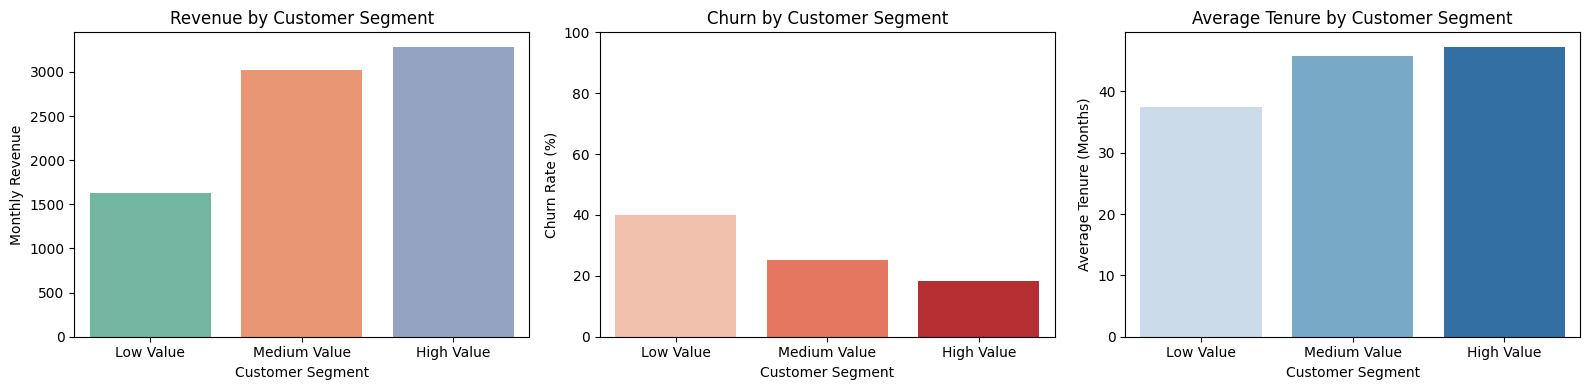

,customer_segment,customers,total_revenue,churn_rate,avg_tenure_months,churn_rate_pct
0,Low Value,187,1632.13,0.401070,37.435829,40.106952
1,Medium Value,203,3016.97,0.251232,45.854680,25.123153
2,High Value,131,3284.69,0.183206,47.279389,18.320611


In [44]:
# Customer segmentation using monthly charges
segment_summary = (
    df.groupby('customer_segment', observed=False)
      .agg(
          customers=('customerid', 'nunique'),
          total_revenue=('monthly_charges', 'sum'),
          churn_rate=('churn_flag', 'mean'),
          avg_tenure_months=('tenure_months', 'mean')
      )
      .reset_index()
)
segment_summary['churn_rate_pct'] = segment_summary['churn_rate'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=segment_summary, x='customer_segment', y='total_revenue', palette='Set2', ax=axes[0])
axes[0].set_title('Revenue by Customer Segment')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Monthly Revenue')

sns.barplot(data=segment_summary, x='customer_segment', y='churn_rate_pct', palette='Reds', ax=axes[1])
axes[1].set_title('Churn by Customer Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 100)

sns.barplot(data=segment_summary, x='customer_segment', y='avg_tenure_months', palette='Blues', ax=axes[2])
axes[2].set_title('Average Tenure by Customer Segment')
axes[2].set_xlabel('Customer Segment')
axes[2].set_ylabel('Average Tenure (Months)')

plt.tight_layout()
plt.show()

segment_summary

**Business Insight:** High Value customers generate the highest monthly revenue at Rs 3,284.69, have the longest average tenure at 47.28 months, and show the lowest churn rate at 18.32%. Low Value customers have the highest churn rate at 40.11%, so retention efforts should focus on moving low-value customers toward stronger plan value or longer contracts.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\333857016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_lost_by_plan, x='plan_type', y='revenue_lost', palette='Reds')


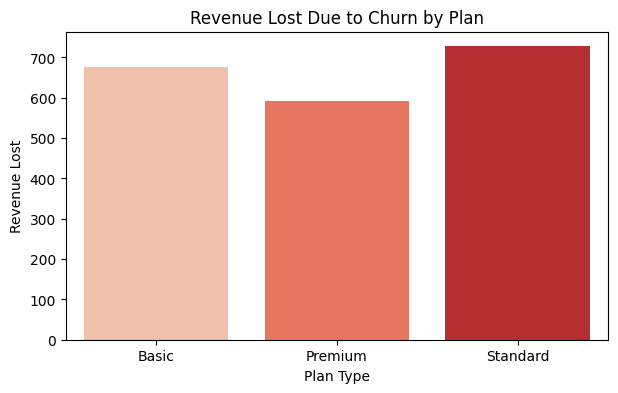

,plan_type,revenue_lost,churned_customers
2,Standard,727.51,49
0,Basic,675.24,76
1,Premium,591.75,25


In [45]:
# Revenue lost due to churn
revenue_lost_by_plan = (
    df.groupby('plan_type')
      .agg(revenue_lost=('revenue_lost', 'sum'), churned_customers=('churn_flag', 'sum'))
      .reset_index()
)

plt.figure(figsize=(7, 4))
sns.barplot(data=revenue_lost_by_plan, x='plan_type', y='revenue_lost', palette='Reds')
plt.title('Revenue Lost Due to Churn by Plan')
plt.xlabel('Plan Type')
plt.ylabel('Revenue Lost')
plt.show()

revenue_lost_by_plan.sort_values('revenue_lost', ascending=False)

**Business Insight:** Standard plan customers account for the highest revenue lost at Rs 727.51, followed by Basic at Rs 675.24 and Premium at Rs 591.75. Reducing Standard and Basic plan churn would recover the largest share of lost recurring revenue.

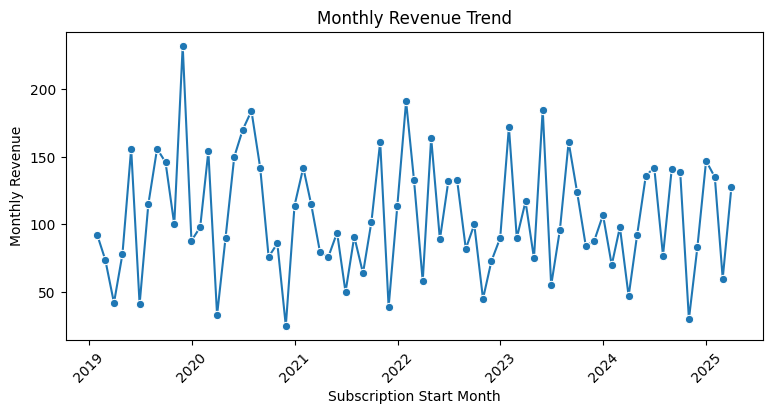

,subscription_start_date,monthly_charges
70,2024-11-30,82.94
71,2024-12-31,146.92
72,2025-01-31,134.91
73,2025-02-28,59.96
74,2025-03-31,127.93


In [46]:
# Monthly revenue trend using subscription start dates
monthly_revenue = (
    df.set_index('subscription_start_date')
      .resample('ME')['monthly_charges']
      .sum()
      .reset_index()
)

plt.figure(figsize=(9, 4))
sns.lineplot(data=monthly_revenue, x='subscription_start_date', y='monthly_charges', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Subscription Start Month')
plt.ylabel('Monthly Revenue')
plt.xticks(rotation=45)
plt.show()

monthly_revenue.tail()

**Business Insight:** Monthly revenue is driven by subscription start timing and plan mix. The trend helps identify months where new customer revenue increased and can be compared with future acquisition campaigns.

In [47]:
# Top 10 revenue customers
top_revenue_customers = df.sort_values('monthly_charges', ascending=False).head(10)[
    ['customerid', 'customer_name', 'plan_type', 'contract_type', 'monthly_charges', 'churn_flag', 'churn_risk']
]

top_revenue_customers

,customerid,customer_name,plan_type,contract_type,monthly_charges,churn_flag,churn_risk
14,0019-GFNTW,Madhav,Premium,Annual,92.99,0,Low
30,1009-PZNGD,vihaan,Premium,Monthly,29.99,1,Low
40,1019-EGNVM,kabir,Premium,Monthly,29.99,0,Medium
432,1411-ZXKVO,ayaan,Premium,Annual,29.99,0,Medium
444,1423-RIIMU,dev,Premium,Monthly,29.99,0,Medium
450,1429-WRXLH,rahul,Premium,Annual,29.99,0,Low
449,1428-XJRPZ,pooja,Premium,Monthly,29.99,0,Low
464,1443-HXIFI,aarav,Premium,Monthly,29.99,1,High
490,1469-KFSNH,meera,Premium,Monthly,29.99,0,Low
394,1373-CYTTO,neha,Premium,Monthly,29.99,0,Low


**Business Insight:** The top monthly-revenue customers are mainly Premium customers. High-paying customers should be monitored by churn risk so the business protects revenue before cancellation happens.

## 7. Complaint Analysis

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\757649686.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=complaint_churn, x='has_complaint', y='churn_rate_pct', palette='Set2')


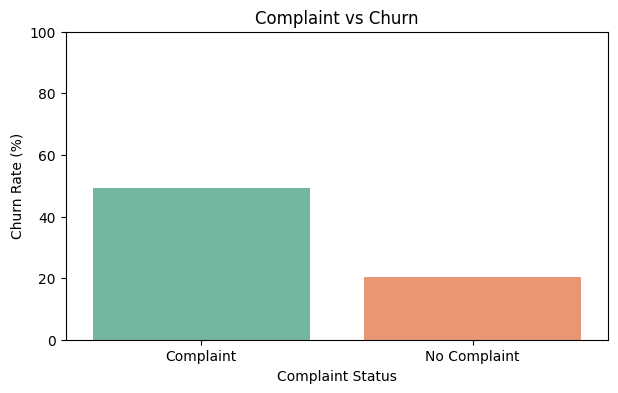

,has_complaint,customers,churn_rate,avg_complaints,churn_rate_pct
0,Complaint,152,0.493421,1.486842,49.342105
1,No Complaint,369,0.203252,0.000000,20.325203


In [48]:
# Complaint vs churn
complaint_churn = (
    df.assign(has_complaint=np.where(df['complaint_count'] > 0, 'Complaint', 'No Complaint'))
      .groupby('has_complaint')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'), avg_complaints=('complaint_count', 'mean'))
      .reset_index()
)
complaint_churn['churn_rate_pct'] = complaint_churn['churn_rate'] * 100

plt.figure(figsize=(7, 4))
sns.barplot(data=complaint_churn, x='has_complaint', y='churn_rate_pct', palette='Set2')
plt.title('Complaint vs Churn')
plt.xlabel('Complaint Status')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

complaint_churn

**Business Insight:** Customers with complaints churn at 49.34%, while customers without complaints churn at 20.33%. This strongly suggests complaint handling is connected to retention in this dataset.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\2002787806.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=complaint_type_churn, x='complaint_type', y='churn_rate_pct', palette='rocket')


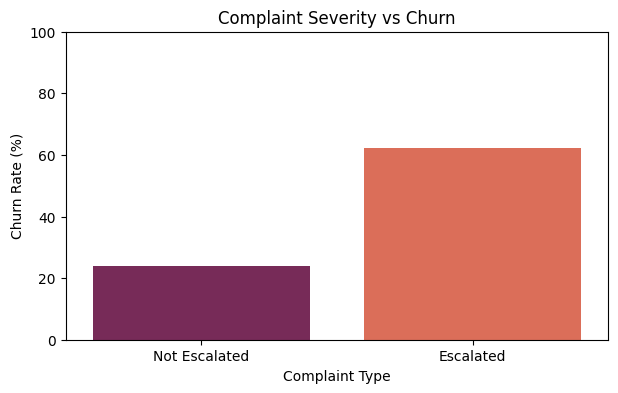

,complaint_type,customers,churn_rate_pct,avg_csat
0,Not Escalated,455,23.956044,56.149451
1,Escalated,66,62.121212,31.560606


In [49]:
# Complaint type vs churn using escalation as complaint severity
complaint_type_churn = (
    df.groupby('escalations')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'), avg_csat=('csat_score', 'mean'))
      .reset_index()
)
complaint_type_churn['complaint_type'] = complaint_type_churn['escalations'].map({'Y': 'Escalated', 'N': 'Not Escalated'})
complaint_type_churn['churn_rate_pct'] = complaint_type_churn['churn_rate'] * 100

plt.figure(figsize=(7, 4))
sns.barplot(data=complaint_type_churn, x='complaint_type', y='churn_rate_pct', palette='rocket')
plt.title('Complaint Severity vs Churn')
plt.xlabel('Complaint Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

complaint_type_churn[['complaint_type', 'customers', 'churn_rate_pct', 'avg_csat']]

**Business Insight:** Escalated complaint customers have a 62.12% churn rate, compared with 23.96% for non-escalated customers. Escalation should be treated as a high-priority churn warning signal.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\297381949.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=complaints_by_plan, x='plan_type', y='avg_complaints', palette='Set3')


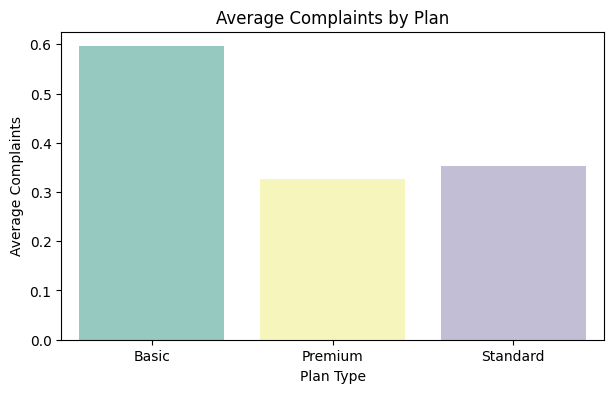

,plan_type,avg_complaints,customers
0,Basic,0.595745,188
2,Standard,0.353234,201
1,Premium,0.325758,132


In [50]:
# Average complaints by plan
complaints_by_plan = (
    df.groupby('plan_type')
      .agg(avg_complaints=('complaint_count', 'mean'), customers=('customerid', 'nunique'))
      .reset_index()
)

plt.figure(figsize=(7, 4))
sns.barplot(data=complaints_by_plan, x='plan_type', y='avg_complaints', palette='Set3')
plt.title('Average Complaints by Plan')
plt.xlabel('Plan Type')
plt.ylabel('Average Complaints')
plt.show()

complaints_by_plan.sort_values('avg_complaints', ascending=False)

**Business Insight:** Basic plan customers have the highest average complaint count at 0.60 complaints per customer. This supports the churn finding that the Basic plan needs product or service improvement.

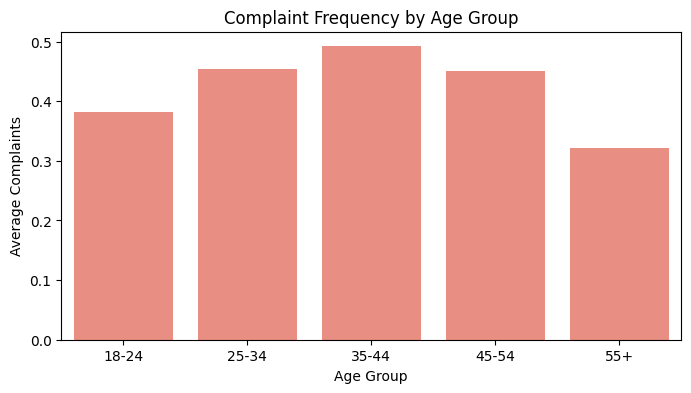

,age_group,avg_complaints,customers
0,18-24,0.381818,55
1,25-34,0.454545,143
2,35-44,0.492063,126
3,45-54,0.451327,113
4,55+,0.321429,84


In [51]:
# Complaint frequency by age group
complaints_by_age = (
    df.groupby('age_group', observed=False)
      .agg(avg_complaints=('complaint_count', 'mean'), customers=('customerid', 'nunique'))
      .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=complaints_by_age, x='age_group', y='avg_complaints', color='salmon')
plt.title('Complaint Frequency by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Complaints')
plt.show()

complaints_by_age

**Business Insight:** Customers aged 35-44 have the highest average complaint frequency at 0.49 complaints per customer, followed by 25-34 at 0.45 and 45-54 at 0.45. These groups should receive clearer support and communication.

## 8. Churn Analysis

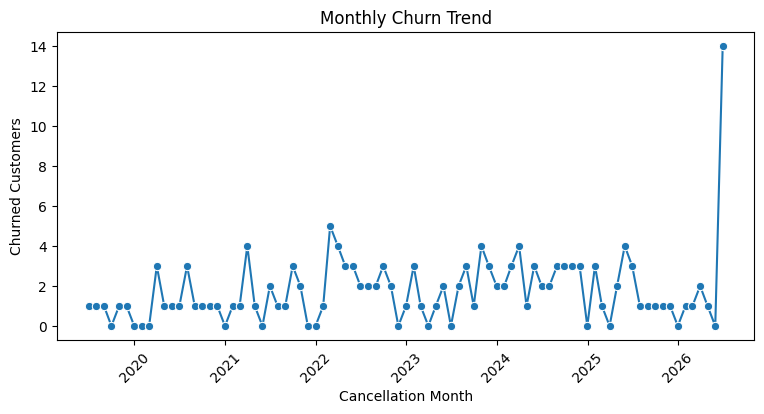

,cancellation_date,churned_customers
0,2019-06-30,1
1,2019-07-31,1
2,2019-08-31,1
3,2019-09-30,0
4,2019-10-31,1
...,...,...
80,2026-02-28,1
81,2026-03-31,2
82,2026-04-30,1
83,2026-05-31,0


In [52]:
# Monthly churn trend
monthly_churn = (
    df[df['churn_flag'] == 1]
      .set_index('cancellation_date')
      .resample('ME')['customerid']
      .nunique()
      .reset_index(name='churned_customers')
)

plt.figure(figsize=(9, 4))
sns.lineplot(data=monthly_churn, x='cancellation_date', y='churned_customers', marker='o')
plt.title('Monthly Churn Trend')
plt.xlabel('Cancellation Month')
plt.ylabel('Churned Customers')
plt.xticks(rotation=45)
plt.show()

monthly_churn

**Business Insight:** Monthly churn activity is concentrated in the observed cancellation months. Tracking this trend helps leadership connect churn spikes with business events such as pricing changes, poor service periods, or competitor offers.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\508799207.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_summary, x='churn_risk', y='customers', order=risk_order, palette='coolwarm')


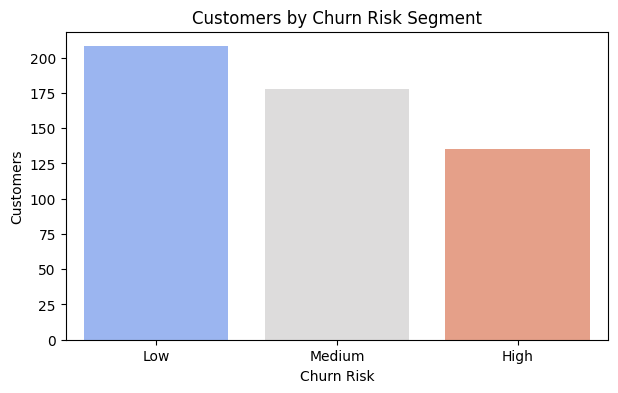

,churn_risk,customers,churn_rate,churn_rate_pct
0,Low,208,0.081731,8.173077
1,Medium,178,0.303371,30.337079
2,High,135,0.585185,58.518519


In [53]:
# Churn risk distribution
risk_order = ['Low', 'Medium', 'High']
risk_summary = (
    df.groupby('churn_risk')
      .agg(customers=('customerid', 'nunique'), churn_rate=('churn_flag', 'mean'))
      .reindex(risk_order)
      .reset_index()
)
risk_summary['churn_rate_pct'] = risk_summary['churn_rate'] * 100

plt.figure(figsize=(7, 4))
sns.barplot(data=risk_summary, x='churn_risk', y='customers', order=risk_order, palette='coolwarm')
plt.title('Customers by Churn Risk Segment')
plt.xlabel('Churn Risk')
plt.ylabel('Customers')
plt.show()

risk_summary

**Business Insight:** The High risk segment contains 135 customers and has a 58.52% churn rate. Medium risk customers churn at 30.34%, while Low risk customers churn at 8.17%, so churn score is a strong prioritization signal in this dataset.

C:\Users\Raunak Prabhakar\AppData\Local\Temp\ipykernel_73252\15512254.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_reasons, x='cancellation_reason', y='churned_customers', palette='mako')


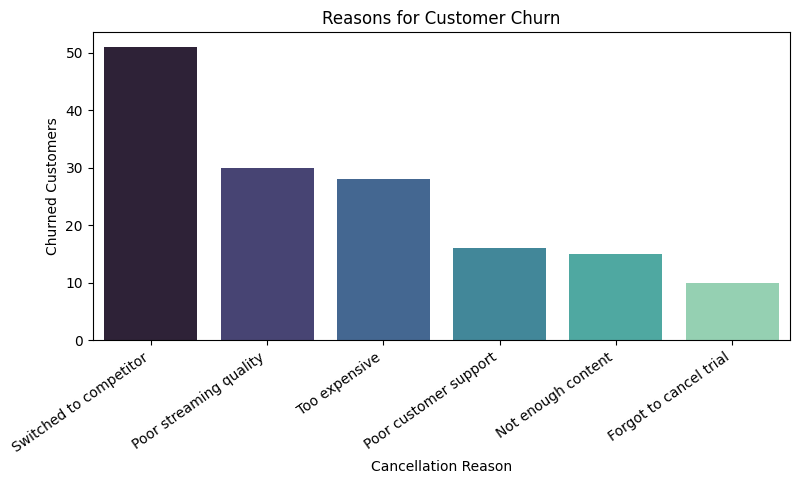

,cancellation_reason,churned_customers
4,Switched to competitor,51
3,Poor streaming quality,30
5,Too expensive,28
2,Poor customer support,16
1,Not enough content,15
0,Forgot to cancel trial,10


In [54]:
# Churn reasons
churn_reasons = (
    df[df['churn_flag'] == 1]
      .groupby('cancellation_reason')
      .agg(churned_customers=('customerid', 'nunique'))
      .reset_index()
      .sort_values('churned_customers', ascending=False)
)

plt.figure(figsize=(9, 4))
sns.barplot(data=churn_reasons, x='cancellation_reason', y='churned_customers', palette='mako')
plt.title('Reasons for Customer Churn')
plt.xlabel('Cancellation Reason')
plt.ylabel('Churned Customers')
plt.xticks(rotation=35, ha='right')
plt.show()

churn_reasons

**Business Insight:** Switched to competitor is the top churn reason with 51 customers, followed by poor streaming quality with 30 customers and too expensive with 28 customers. Competitive positioning, streaming quality, and pricing should be the main churn-reduction focus areas.

## 9. Key Findings

- Overall churn rate is 28.79%, with 150 churned customers out of 521 total customers.
- Monthly contract customers churn at 34.06%, compared with 20.20% for annual contract customers, making monthly customers about 1.7 times more likely to churn.
- Customers with complaints churn at 49.34%, while customers without complaints churn at 20.33%.
- Premium plan customers generate the highest monthly revenue at Rs 3,297.68 and have the lowest churn rate at 18.94%.
- Rs 1,994.50 of monthly recurring revenue has been lost due to churn.
- High Value customers generate Rs 3,284.69 in monthly revenue and have the lowest churn rate at 18.32%, while Low Value customers have the highest segment churn rate at 40.11%.

## 10. Recommendations

- Prioritize monthly contract customers with retention offers because they churn at 34.06%.
- Improve support response time for complaint and escalation cases because customers with complaints churn at 49.34% and escalated customers churn at 62.12%.
- Review the Basic plan experience because it has the highest churn rate at 40.43% and the highest average complaint count at 0.60 complaints per customer.
- Protect Premium customers with loyalty rewards because they generate 41.57% of total monthly revenue and have the lowest plan-level churn rate.
- Monitor Low Value customers closely because they have the highest segment churn rate at 40.11%.

I